# Hand Gesture Recognition with PyTorch

## Overview

This project demonstrates an end-to-end deep learning workflow for recognizing American Sign Language (ASL) hand gestures using Convolutional Neural Networks (CNNs) in PyTorch. It covers the complete computer vision pipeline, from custom dataset creation and preprocessing to model training, evaluation, and transfer learning using pretrained convolutional neural networks.

## Learning Objectives

By completing this project, you will learn how to:

- Build a custom image dataset for hand gesture recognition
- Preprocess and organize image data for deep learning
- Split datasets into training, validation, and testing sets
- Implement and train Convolutional Neural Networks (CNNs) in PyTorch
- Apply transfer learning using pretrained computer vision models
- Evaluate image classification models using appropriate performance metrics
- Improve model generalization through data augmentation and regularization techniques
- Visualize training progress and model predictions

This notebook demonstrates practical computer vision techniques that can be applied to a wide range of image classification tasks beyond hand gesture recognition.

# Part 1

# Part A — Dataset Preparation

## Overview

High-quality datasets are essential for building reliable computer vision models. Unlike benchmark datasets such as MNIST or CIFAR, many real-world applications require collecting, organizing, and preprocessing custom image datasets before model development can begin.

This project demonstrates the complete workflow for creating a custom dataset for hand gesture recognition, including image collection, preprocessing, quality control, and dataset organization.

---

## American Sign Language (ASL)

American Sign Language (ASL) is a complete visual language that communicates through hand gestures, facial expressions, and body posture. In this project, we focus on recognizing a subset of ASL alphabet gestures using deep learning.

Specifically, the classification task consists of recognizing hand gestures corresponding to the letters:

**A – I (9 gesture classes)**

![ASL Alphabet](https://www.disabled-world.com/pics/1/asl-alphabet.jpg)

---

## Dataset Collection

A custom dataset is created by capturing multiple images for each ASL hand gesture.

### Recommended Data Collection Guidelines

- Capture multiple images for each gesture from slightly different viewpoints.
- Ensure consistent lighting conditions.
- Use a clean, uncluttered background whenever possible.
- Keep the hand clearly visible and centered in the image.
- Minimize shadows and background distractions.
- Capture sufficient variation to improve model generalization.

---

## Image Preprocessing

To ensure consistent model performance, all images are standardized before training.

### Preprocessing Steps

- Crop the hand region
- Resize all images to **224 × 224 pixels**
- Preserve RGB color channels
- Center the hand within the image
- Save images in JPEG format

These preprocessing steps reduce unnecessary variation and improve the quality of the training dataset.

---

## Dataset Organization

The dataset is organized into one directory for each gesture class:

```text
dataset/
│
├── A/
├── B/
├── C/
├── D/
├── E/
├── F/
├── G/
├── H/
└── I/
```

Each folder contains multiple images representing the corresponding ASL gesture.

---

## Example Dataset

The figure below illustrates examples from the hand gesture dataset used for training the convolutional neural network.

![Example Dataset](https://github.com/UTNeural/APS360/blob/master/Gesture%20Images.PNG?raw=true)

# Part B — Building a Convolutional Neural Network

## Overview

In this section, a Convolutional Neural Network (CNN) is implemented from scratch using PyTorch to classify American Sign Language (ASL) hand gestures. The model is trained on the prepared dataset and evaluated on unseen images to assess its ability to generalize.

The implementation demonstrates the complete deep learning workflow, including model architecture design, training, validation, performance evaluation, and prediction.

## Objectives

The goals of this section are to:

- Design and implement a Convolutional Neural Network (CNN) in PyTorch
- Train the network for multi-class image classification
- Monitor training and validation performance
- Evaluate the trained model on unseen test data
- Analyze model accuracy and learning behavior
- Explore techniques for improving generalization and reducing overfitting

## Implementation Notes

The CNN is implemented using PyTorch's neural network modules. The training pipeline follows modern deep learning practices, including:

- Efficient mini-batch training with `DataLoader`
- GPU acceleration (when available)
- Vectorized tensor operations
- Training and validation loops
- Loss and accuracy monitoring
- Model evaluation on a held-out test set

Throughout this section, training and validation metrics are visualized to better understand the learning process and evaluate model performance.

# Part 2 — Data Loading and Dataset Splitting

## Overview

The dataset is loaded using PyTorch's `torchvision.datasets.ImageFolder`, which automatically assigns class labels based on the directory structure. Images are then transformed into tensors and organized into training, validation, and test datasets.

### Dataset Splitting Strategy

The dataset is randomly partitioned into three non-overlapping subsets using PyTorch's `random_split` function:

- **Training set:** 80%
- **Validation set:** 10%
- **Test set:** 10%

This strategy ensures that:

- The model is trained only on the training data.
- The validation set is used for model selection and hyperparameter tuning.
- The test set remains completely unseen during training and validation, providing an unbiased estimate of the model's generalization performance.

The three subsets are mutually exclusive, ensuring that no image appears in more than one dataset.

### Dataset Statistics

| Dataset | Images |
|---------|-------:|
| Training | 1,920 |
| Validation | 256 |
| Test | 255 |
| **Total** | **2,431** |

### Data Loading

The dataset is loaded using PyTorch's `ImageFolder` class, which automatically reads images from class-specific folders and assigns the appropriate labels. This approach provides a simple and scalable pipeline for image classification tasks and integrates seamlessly with PyTorch's `DataLoader` for efficient mini-batch training.


Dataset:https://drive.google.com/file/d/1tzxyXdI3-nL2YZwUfNjtQb7sl1BJ1A-J/view?usp=sharing

In [4]:
import glob
import os
import zipfile
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import torch.utils.data as data
import torchvision
from torchvision import datasets, transforms
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler
import gdown

# 1. Download the zip file directly via the shared link
shared_url = 'https://drive.google.com/file/d/1tzxyXdI3-nL2YZwUfNjtQb7sl1BJ1A-J/view?usp=sharing'
zip_output = 'Lab_3b_Gesture_Dataset.zip'
extract_path = 'Lab_3b_Gesture_Dataset'

if not os.path.exists(zip_output):
    print("Downloading dataset from Google Drive...")
    gdown.download(url=shared_url, output=zip_output, quiet=False)

# 2. Unzip the file to the local Colab disk
if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_output, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction completed!")
else:
    print("Dataset already extracted.")

# 3. Data Transformations
normalizer = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))

transformed = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalizer
])

# 4. Load Data (Fixed: root now points to the locally extracted path)
images_all = torchvision.datasets.ImageFolder(root=extract_path, transform=transformed)

# 5. Split Dataset Dynamically (Safe from manual calculation errors)
torch.manual_seed(100)
total_count = len(images_all)

# Set up your split sizes mathematically based on your target counts
train_count = 1920
val_count = 256
test_count = total_count - train_count - val_count  # Remainder goes to test set safely

train_set, val_set, test_set = torch.utils.data.random_split(images_all, [train_count, val_count, test_count])

print(f"Total dataset size: {total_count}")
print(f"Split sizes -> Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

# Note: Removed train_set = list(train_set) to preserve RAM stability.
# You can pass train_set directly into a torch.utils.data.DataLoader now!

Downloading...
From (original): https://drive.google.com/uc?id=1tzxyXdI3-nL2YZwUfNjtQb7sl1BJ1A-J
From (redirected): https://drive.google.com/uc?id=1tzxyXdI3-nL2YZwUfNjtQb7sl1BJ1A-J&confirm=t&uuid=476c6e7f-405c-404a-8be3-785307d885b4
To: /Users/miladsaeedi/Desktop/Daily_Work_load/Github/Lab_3b_Gesture_Dataset.zip
100%|██████████| 42.1M/42.1M [00:01<00:00, 38.3MB/s]


Extracting dataset...
Extraction completed!
Total dataset size: 2431
Split sizes -> Train: 1920, Val: 256, Test: 255



<font color=Blue> Visualizing some images <font color=black>

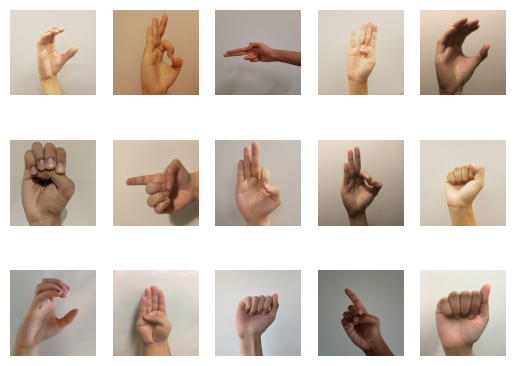

In [5]:
import matplotlib.pyplot as plt
k = 0
for images, labels in torch.utils.data.DataLoader(train_set, batch_size=1):
  #  since batch_size = 1, there is only 1 image in `images`
  image = images[0]
    # place the colour channel at the end, instead of at the beginning
  img = np.transpose(image, [1,2,0])
    # normalize pixel intensity values to [0, 1]
  img = img / 2 + 0.5
  plt.subplot(3, 5, k+1)
  plt.axis('off')
  plt.imshow(img)

  k += 1
  if k > 14:
    break

## Part 2. Model Building and Sanity Checking

### Part 2(a) — Convolutional Neural Network Architecture

A custom Convolutional Neural Network (CNN) was developed for multi-class hand gesture classification. Multiple CNN architectures were explored and compared during development, and the final model was selected based on its classification performance while maintaining a relatively small number of trainable parameters for efficient training.

### Model Architecture

The final network consists of:

- **Two convolutional layers** for hierarchical feature extraction.
- **Two fully connected (linear) layers** for image classification.
- **ReLU activation functions** after each convolutional layer to introduce non-linearity and enable efficient gradient propagation during training.
- **Max-pooling layers** with a kernel size of **2 × 2** and stride **2** to progressively reduce the spatial dimensions while retaining the most informative features.
- A **stride of 4** in the first convolutional layer to reduce the spatial resolution early in the network, decreasing the number of parameters required in the fully connected layers and improving computational efficiency.

### Design Choices

- The number of output channels is defined as a configurable hyperparameter, allowing the architecture to be easily tuned during experimentation.
- The number of hidden units in the first fully connected layer is determined by the output size of the final convolutional layer. For example, when the second convolutional layer has **10 output channels**, the flattened feature vector contains **250 features (10 × 5 × 5)**.
- A relatively lightweight architecture was selected to balance classification performance, computational cost, and training time while achieving good generalization on the hand gesture dataset.

In [6]:
# Convolutional Neural Network Architecture
class Classifier(nn.Module):
    def __init__(self, output_conv1, output_conv2):
        super(Classifier, self).__init__()
        self.conv1 = nn.Conv2d(3, output_conv1, 10, 4)     # in_channels, out_channels, kernel_size
        self.pool = nn.MaxPool2d(2, 2)                     # kernel_size, stride
        self.conv2 = nn.Conv2d(output_conv1, output_conv2, 7, 2)  # in_channels, out_channels, kernel_size
        self.fc1 = nn.Linear(output_conv2 * 5 * 5, 32)
        self.fc2 = nn.Linear(32, 9)
        self.a = output_conv2

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, self.a * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
model = Classifier( output_conv1=10, output_conv2=20)
N_p_large=0
for param in model.parameters():
      N_p_large+=param.numel()
print('Total number of parameters in large_net= ', N_p_large)

Total number of parameters in large_net=  29159


#### <font color=blue> Note: two more architecture has been tried, but the accuracy was slightly lower and number of parameters higher for them. <font color=blue>

In [8]:
  # class Classifier(nn.Module):
  #     def __init__(self, output_conv1):
  #         super(Classifier, self).__init__()
  #         self.conv1 = nn.Conv2d(3, output_conv1, 5) #in_channels, out_chanels, kernel_size
  #         self.pool = nn.MaxPool2d(2, 2) #kernel_size, stride
  #         self.conv2 = nn.Conv2d(output_conv1, 10, 5) #in_channels, out_chanels, kernel_size
  #         self.fc1 = nn.Linear(53*53*10, 32)
  #         self.fc2 = nn.Linear(32, 10)

  #     def forward(self, x):
  #         x = self.pool(F.relu(self.conv1(x)))
  #         x = self.pool(F.relu(self.conv2(x)))
  #         x = x.view(-1, 53*53*10)
  #         x = F.relu(self.fc1(x))
  #         x = self.fc2(x)
  #         return x

In [9]:
  # class Classifier(nn.Module):
  #     def __init__(self):
  #         super(Classifier, self).__init__()
  #         self.conv1 = nn.Conv2d(3, 5, 8,3) #in_channels, out_chanels, kernel_size
  #         self.pool = nn.MaxPool2d(2, 2) #kernel_size, stride
  #         self.conv2 = nn.Conv2d(5, 10, 8,2) #in_channels, out_chanels, kernel_size
  #         self.fc1 = nn.Linear(7*7*10, 32)
  #         self.fc2 = nn.Linear(32, 10)

  #     def forward(self, x):
  #         x = self.pool(F.relu(self.conv1(x)))
  #         x = self.pool(F.relu(self.conv2(x)))
  #         x = x.view(-1, 7*7*10)
  #         x = F.relu(self.fc1(x))
  #         x = self.fc2(x)
  #         return x

### Part 2(b) — Model Training

A reusable training pipeline was implemented to simplify experimentation with different neural network architectures and hyperparameter settings. The training framework allows key parameters such as the learning rate, batch size, number of epochs, and model architecture to be modified with minimal code changes.

### Training Pipeline

The implementation includes:

- A dedicated function for computing classification accuracy.
- A modular training function that performs both training and validation.
- Support for configurable hyperparameters, including:
  - Batch size
  - Learning rate
  - Number of epochs
  - Optimizer
  - Model architecture
- Automatic model checkpointing after every training epoch, allowing intermediate models to be saved and training to be resumed if necessary.

### Loss Function

The model is trained using **Cross-Entropy Loss (`nn.CrossEntropyLoss`)**, which is the standard loss function for multi-class classification problems. It combines the softmax activation and negative log-likelihood into a single objective function, making it well suited for predicting one of multiple gesture classes.

### Optimizer

**Stochastic Gradient Descent (SGD)** is used to optimize the network parameters. Compared with standard batch gradient descent, SGD updates the model more frequently using mini-batches of data, resulting in faster training, lower memory requirements, and often improved convergence and generalization for deep neural networks.

In [10]:
def get_accuracy(model, criterion, batch_size, train=False, test=False):
    if test:
      data=test_set
    else:
      if train:
        data = train_set
      else:
        data = val_set


    correct = 0
    error=0
    total = 0
    total_loss = 0.0
    for i, data in enumerate(torch.utils.data.DataLoader(data, batch_size=batch_size), 0):
        imgs, labels = data
        #############################################
        #To Enable GPU Usage
        if use_cuda and torch.cuda.is_available():
          imgs = imgs.cuda()
          labels = labels.cuda()
        #############################################


        output = model(imgs)

        loss = criterion(output, labels)

        #select index with maximum prediction score
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred)).sum().item()
        error += pred.ne(labels.view_as(pred)).sum().item()
        total += imgs.shape[0]
        total_loss += loss.item()
    acc=correct/ total
    err=error/ total
    loss = float(total_loss) / (i + 1)
    return acc, loss, err


In [11]:
def train(model, data, output_conv1, output_conv2, batch_size=256, learning_rate=0.01, num_epochs=30):
    torch.manual_seed(1000)
    train_loader = torch.utils.data.DataLoader(data, batch_size=batch_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    iters, losses, train_acc, val_acc = [], [], [], []
    losses_val= []
    losses_train= []
    val_err= []
    train_err= []

    # training
    n = 0 # the number of iterations
    start_time = time.time()
    for epoch in range(num_epochs):

        for imgs, labels in iter(train_loader):


            #############################################
            #To Enable GPU Usage
            if use_cuda and torch.cuda.is_available():
              imgs = imgs.cuda()
              labels = labels.cuda()
            #############################################


            out = model(imgs)             # forward pass
            loss = criterion(out, labels) # compute the total loss
            loss.backward()               # backward pass (compute parameter updates)
            optimizer.step()              # make the updates for each parameter
            optimizer.zero_grad()         # a clean up step for PyTorch

            # save the current training information
            iters.append(n)
            losses.append(float(loss)/batch_size)             # compute *average* loss
            train_acc.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=True)[0]) # compute training accuracy
            val_acc.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=False)[0])  # compute validation accuracy
            n += 1

        losses_train.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=True)[1])  # compute validation loss
        losses_val.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=False)[1])  # compute validation loss
        train_err.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=True)[2]) # compute training accuracy
        val_err.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=False)[2])  # compute validation accuracy
        print(("Epoch {}: Train err: {:.3f}, Train loss: {:.3f} |"+
               "Validation err: {:.3f}, Validation loss: {:.3f}").format(
                   epoch + 1,
                   train_err[epoch],
                   losses_train[epoch],
                   val_err[epoch],
                   losses_val[epoch]))

        # Save the current model (checkpoint) to a file
        model_path ="model_bs{0}_lr{1}_epoch{2}_conv{3}_conv{4}".format(batch_size,
                                                   learning_rate,
                                                   epoch,
                                                   output_conv1,
                                                   output_conv2)
        torch.save(model.state_dict(), model_path)
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt("{}_train_err.csv".format(model_path), train_acc)
    np.savetxt("{}_train_loss.csv".format(model_path), losses)
    np.savetxt("{}_val_err.csv".format(model_path), val_acc)
    # np.savetxt("{}_val_loss.csv".format(model_path), val_loss)


    # plotting
    fig = plt.figure(figsize=(12, 10))
    plt.subplot(2, 2, 1)
    plt.title("Training Curve")
    plt.plot(iters, losses, label="Train")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")

    plt.subplot(2, 2, 2)
    plt.title("Training Curve")
    plt.plot(iters, train_acc, label="Train")
    plt.plot(iters, val_acc, label="Validation")
    plt.xlabel("Iterations")
    plt.ylabel("Training Accuracy")
    plt.legend(loc='best')

    x = len(losses_train)
    plt.subplot(2, 2, 3)
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,x+1), losses_train, label="Train")
    plt.plot(range(1,x+1), losses_val, label="Validation")
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')

    plt.subplot(2, 2, 4)
    plt.title("Train vs Validation error")
    plt.plot(range(1,x+1), train_err, label="Train")
    plt.plot(range(1,x+1), val_err, label="Validation")
    plt.xlabel("epoch")
    plt.ylabel("error")
    plt.legend(loc='best')


    print("Final Training Accuracy: {}".format(train_acc[-1]))
    print("Final Validation Accuracy: {}".format(val_acc[-1]))

### Part 2(c) — Model Validation on a Small Dataset

Before training on the full dataset, a sanity check was performed by training the network on a small subset of images. This experiment verifies that both the model architecture and the training pipeline are implemented correctly.

### Validation Strategy

- A subset containing **64 training images** was selected.
- The model was trained using a large batch size so that all images were processed together during each optimization step.
- Training continued until the network was able to memorize the small dataset.

### Results

The model successfully achieved **100% training accuracy** on the 64-image subset, demonstrating that:

- The CNN architecture is capable of learning the training data.
- The forward and backward propagation are implemented correctly.
- The optimization process and loss function operate as expected.
- The data loading and preprocessing pipeline function correctly.

Successfully overfitting a small dataset is a common validation step in deep learning, providing confidence that the model and training pipeline are correctly implemented before scaling to the full dataset.

In [12]:
from torch.utils.data import Subset

# 1. Safely slice the first 32 samples using a Subset wrapper
debug_indices = list(range(32))
debug_data = Subset(train_set, debug_indices)

# 2. Setup your model and GPU config
use_cuda = True

model = Classifier(output_conv1=5, output_conv2=10)

if use_cuda and torch.cuda.is_available():
    model.cuda()
    print('CUDA is available!  Training on GPU ...')
else:
    print('CUDA is not available.  Training on CPU ...')

# 3. Train your model on the debug subset
train(model, debug_data, batch_size=512, output_conv1=5, output_conv2=10, num_epochs=200)

# 4. Obtain accuracy on your 32 debug samples
# Note: Changed your comment/batch size to 32 here since debug_data only has 32 samples.
correct = 0
total = 0
for imgs, labels in torch.utils.data.DataLoader(debug_data, batch_size=32):
    if use_cuda and torch.cuda.is_available():
        imgs = imgs.cuda()
        labels = labels.cuda()

    output = model(imgs)
    # select index with maximum prediction score
    pred = output.max(1, keepdim=True)[1]
    correct += pred.eq(labels.view_as(pred)).sum().item()
    total += imgs.shape[0]

print('Accuracy on debug batch: ', correct / total)

CUDA is not available.  Training on CPU ...


/var/folders/nn/c8hngzbx03v9v7qk14mjl0680000gn/T/ipykernel_55012/1443482189.py:37: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  losses.append(float(loss)/batch_size)             # compute *average* loss


Epoch 1: Train err: 1.000, Train loss: 2.294 |Validation err: 1.000, Validation loss: 2.295
Epoch 2: Train err: 1.000, Train loss: 2.267 |Validation err: 1.000, Validation loss: 2.267
Epoch 3: Train err: 1.000, Train loss: 2.229 |Validation err: 1.000, Validation loss: 2.229
Epoch 4: Train err: 1.000, Train loss: 2.180 |Validation err: 1.000, Validation loss: 2.180
Epoch 5: Train err: 1.000, Train loss: 2.117 |Validation err: 1.000, Validation loss: 2.117
Epoch 6: Train err: 0.427, Train loss: 2.035 |Validation err: 0.418, Validation loss: 2.034
Epoch 7: Train err: 0.001, Train loss: 1.915 |Validation err: 0.000, Validation loss: 1.914
Epoch 8: Train err: 0.000, Train loss: 1.713 |Validation err: 0.000, Validation loss: 1.710
Epoch 9: Train err: 0.000, Train loss: 1.314 |Validation err: 0.000, Validation loss: 1.307
Epoch 10: Train err: 0.000, Train loss: 0.584 |Validation err: 0.000, Validation loss: 0.570
Epoch 11: Train err: 0.000, Train loss: 0.086 |Validation err: 0.000, Validatio

KeyboardInterrupt: 

## Part 3. Hyperparameter Search


### Part 4(a) — Hyperparameter Selection

Several hyperparameters can significantly influence the performance of a convolutional neural network. The following hyperparameters were selected for tuning during model development:

- **Learning rate** – Controls the step size used by the optimizer during parameter updates and has a significant impact on convergence speed and model performance.
- **Batch size** – Determines the number of training samples processed in each optimization step, affecting training stability, convergence, and computational efficiency.
- **Number of output channels in the first convolutional layer** – Controls the number of low-level features extracted from the input images.
- **Number of output channels in the second convolutional layer** – Determines the model's capacity to learn higher-level feature representations before the fully connected layers.

Among these, the **number of output channels in the convolutional layers** is a model architecture hyperparameter, while the **learning rate** and **batch size** are optimization hyperparameters.

### Part 3(b) Tuning for convolutional out_chanels size for first and second convolution layer.

In [13]:

use_cuda = True

model = Classifier(output_conv1=5, output_conv2=10)

if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')


train(model, train_set, output_conv1=5, output_conv2=10)

CUDA is not available.  Training on CPU ...
Epoch 1: Train err: 0.000, Train loss: 1.753 |Validation err: 0.000, Validation loss: 1.753
Epoch 2: Train err: 0.000, Train loss: 0.001 |Validation err: 0.000, Validation loss: 0.001
Epoch 3: Train err: 0.000, Train loss: 0.000 |Validation err: 0.000, Validation loss: 0.000


KeyboardInterrupt: 

CUDA is available!  Training on GPU ...
Epoch 1: Train err: 0.890, Train loss: 2.201 |Validation err: 0.910, Validation loss: 2.197
Epoch 2: Train err: 0.878, Train loss: 2.197 |Validation err: 0.883, Validation loss: 2.195
Epoch 3: Train err: 0.869, Train loss: 2.193 |Validation err: 0.875, Validation loss: 2.193
Epoch 4: Train err: 0.792, Train loss: 2.187 |Validation err: 0.820, Validation loss: 2.189
Epoch 5: Train err: 0.764, Train loss: 2.176 |Validation err: 0.816, Validation loss: 2.180
Epoch 6: Train err: 0.780, Train loss: 2.151 |Validation err: 0.812, Validation loss: 2.159
Epoch 7: Train err: 0.764, Train loss: 2.089 |Validation err: 0.824, Validation loss: 2.101
Epoch 8: Train err: 0.632, Train loss: 1.916 |Validation err: 0.672, Validation loss: 1.936
Epoch 9: Train err: 0.495, Train loss: 1.487 |Validation err: 0.559, Validation loss: 1.574
Epoch 10: Train err: 0.451, Train loss: 1.309 |Validation err: 0.504, Validation loss: 1.542
Epoch 11: Train err: 0.382, Train loss:

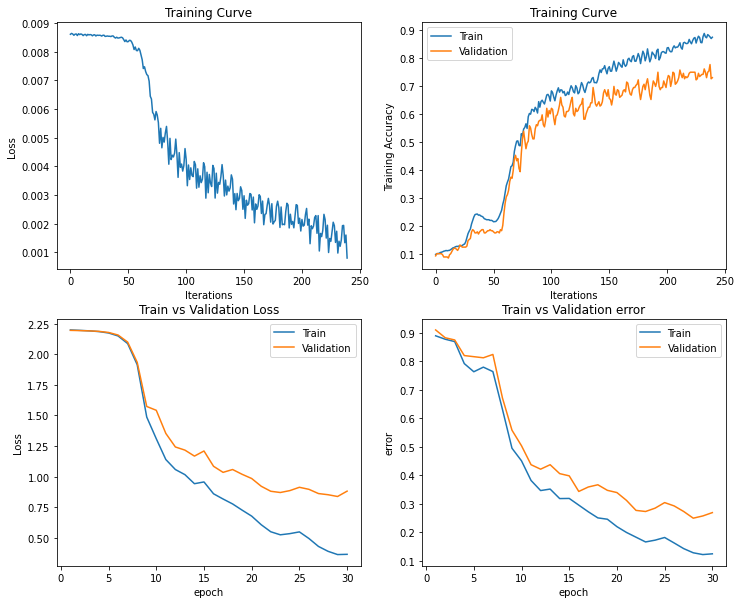

In [ ]:
import time
use_cuda = True

model = Classifier(output_conv1=10, output_conv2=10)

if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')


train(model, train_set, output_conv1=10, output_conv2=10)

CUDA is available!  Training on GPU ...
Epoch 1: Train err: 0.887, Train loss: 2.201 |Validation err: 0.895, Validation loss: 2.202
Epoch 2: Train err: 0.887, Train loss: 2.196 |Validation err: 0.895, Validation loss: 2.197
Epoch 3: Train err: 0.887, Train loss: 2.188 |Validation err: 0.895, Validation loss: 2.190
Epoch 4: Train err: 0.842, Train loss: 2.173 |Validation err: 0.848, Validation loss: 2.175
Epoch 5: Train err: 0.811, Train loss: 2.136 |Validation err: 0.836, Validation loss: 2.137
Epoch 6: Train err: 0.690, Train loss: 2.026 |Validation err: 0.766, Validation loss: 2.029
Epoch 7: Train err: 0.537, Train loss: 1.692 |Validation err: 0.617, Validation loss: 1.731
Epoch 8: Train err: 0.479, Train loss: 1.442 |Validation err: 0.512, Validation loss: 1.627
Epoch 9: Train err: 0.443, Train loss: 1.368 |Validation err: 0.500, Validation loss: 1.604
Epoch 10: Train err: 0.371, Train loss: 1.180 |Validation err: 0.434, Validation loss: 1.324
Epoch 11: Train err: 0.323, Train loss:

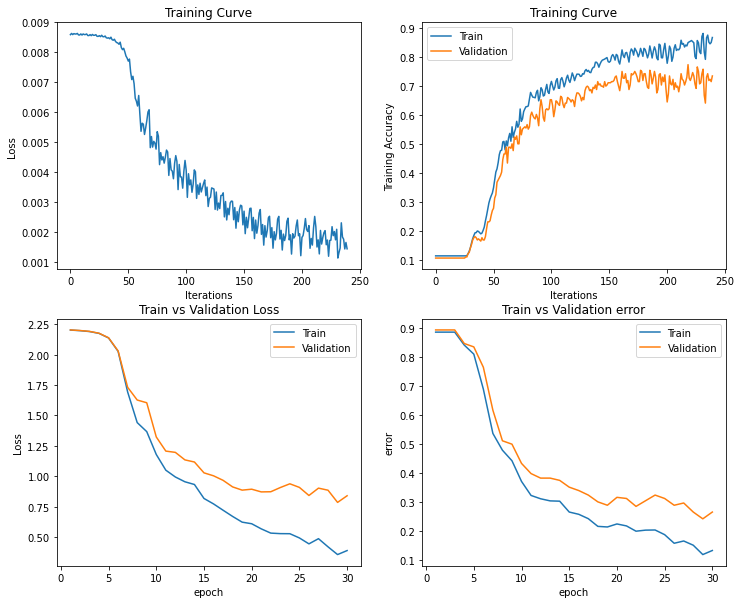

In [ ]:
import time
use_cuda = True

model = Classifier(output_conv1=10, output_conv2=20)

if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')


train(model, train_set, output_conv1=10, output_conv2=20)

CUDA is available!  Training on GPU ...
Epoch 1: Train err: 0.883, Train loss: 2.195 |Validation err: 0.902, Validation loss: 2.208
Epoch 2: Train err: 0.883, Train loss: 2.192 |Validation err: 0.902, Validation loss: 2.205
Epoch 3: Train err: 0.879, Train loss: 2.186 |Validation err: 0.902, Validation loss: 2.199
Epoch 4: Train err: 0.855, Train loss: 2.173 |Validation err: 0.875, Validation loss: 2.187
Epoch 5: Train err: 0.778, Train loss: 2.141 |Validation err: 0.812, Validation loss: 2.157
Epoch 6: Train err: 0.714, Train loss: 2.050 |Validation err: 0.730, Validation loss: 2.072
Epoch 7: Train err: 0.586, Train loss: 1.797 |Validation err: 0.629, Validation loss: 1.834
Epoch 8: Train err: 0.515, Train loss: 1.463 |Validation err: 0.562, Validation loss: 1.559
Epoch 9: Train err: 0.398, Train loss: 1.228 |Validation err: 0.496, Validation loss: 1.412
Epoch 10: Train err: 0.343, Train loss: 1.086 |Validation err: 0.430, Validation loss: 1.297
Epoch 11: Train err: 0.299, Train loss:

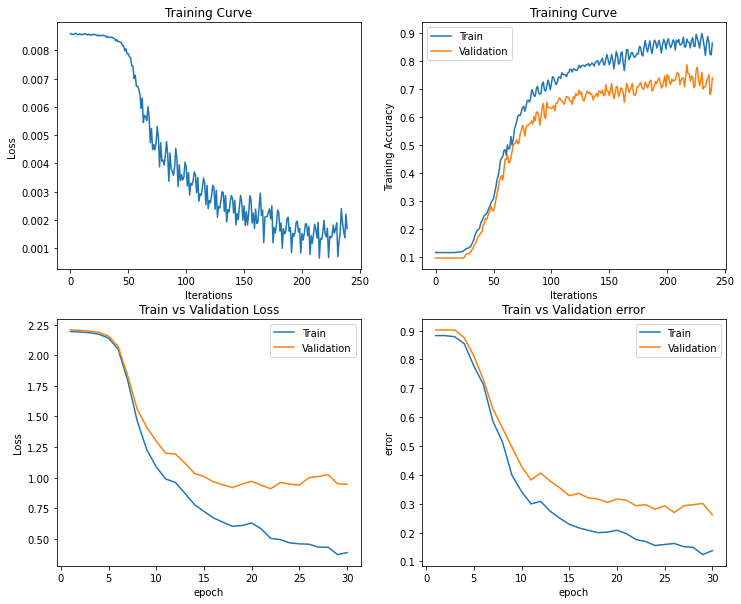

In [ ]:
import time
use_cuda = True

model = Classifier(output_conv1=5, output_conv2=20)

if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')


train(model, train_set, output_conv1=5, output_conv2=20)

#### <font color=Blue> tunning batch_size <font color=Blue>

CUDA is available!  Training on GPU ...
Epoch 1: Train err: 0.883, Train loss: 2.196 |Validation err: 0.902, Validation loss: 2.209
Epoch 2: Train err: 0.883, Train loss: 2.195 |Validation err: 0.902, Validation loss: 2.208
Epoch 3: Train err: 0.883, Train loss: 2.194 |Validation err: 0.902, Validation loss: 2.207
Epoch 4: Train err: 0.883, Train loss: 2.192 |Validation err: 0.902, Validation loss: 2.205
Epoch 5: Train err: 0.882, Train loss: 2.189 |Validation err: 0.902, Validation loss: 2.202
Epoch 6: Train err: 0.879, Train loss: 2.186 |Validation err: 0.902, Validation loss: 2.199
Epoch 7: Train err: 0.871, Train loss: 2.181 |Validation err: 0.895, Validation loss: 2.194
Epoch 8: Train err: 0.857, Train loss: 2.174 |Validation err: 0.875, Validation loss: 2.187
Epoch 9: Train err: 0.823, Train loss: 2.162 |Validation err: 0.859, Validation loss: 2.176
Epoch 10: Train err: 0.781, Train loss: 2.143 |Validation err: 0.812, Validation loss: 2.158
Epoch 11: Train err: 0.742, Train loss:

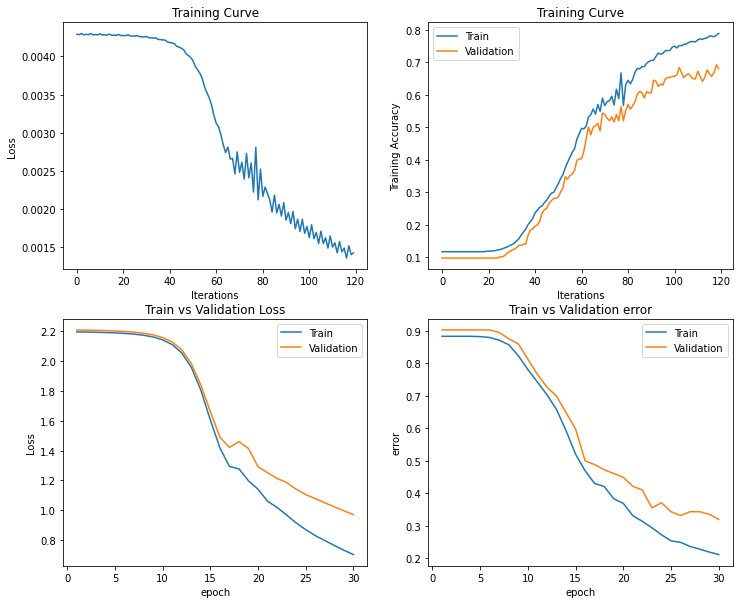

In [ ]:
use_cuda = True

model = Classifier(output_conv1=5, output_conv2=20)

if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')


train(model, train_set, output_conv1=5, output_conv2=20, batch_size=512)

CUDA is available!  Training on GPU ...
Epoch 1: Train err: 0.865, Train loss: 2.200 |Validation err: 0.875, Validation loss: 2.204
Epoch 2: Train err: 0.845, Train loss: 2.195 |Validation err: 0.859, Validation loss: 2.199
Epoch 3: Train err: 0.814, Train loss: 2.183 |Validation err: 0.820, Validation loss: 2.189
Epoch 4: Train err: 0.792, Train loss: 2.136 |Validation err: 0.836, Validation loss: 2.144
Epoch 5: Train err: 0.634, Train loss: 1.875 |Validation err: 0.695, Validation loss: 1.909
Epoch 6: Train err: 0.477, Train loss: 1.433 |Validation err: 0.523, Validation loss: 1.530
Epoch 7: Train err: 0.378, Train loss: 1.125 |Validation err: 0.438, Validation loss: 1.286
Epoch 8: Train err: 0.331, Train loss: 0.974 |Validation err: 0.406, Validation loss: 1.183
Epoch 9: Train err: 0.266, Train loss: 0.841 |Validation err: 0.375, Validation loss: 1.058
Epoch 10: Train err: 0.228, Train loss: 0.739 |Validation err: 0.352, Validation loss: 0.950
Epoch 11: Train err: 0.225, Train loss:

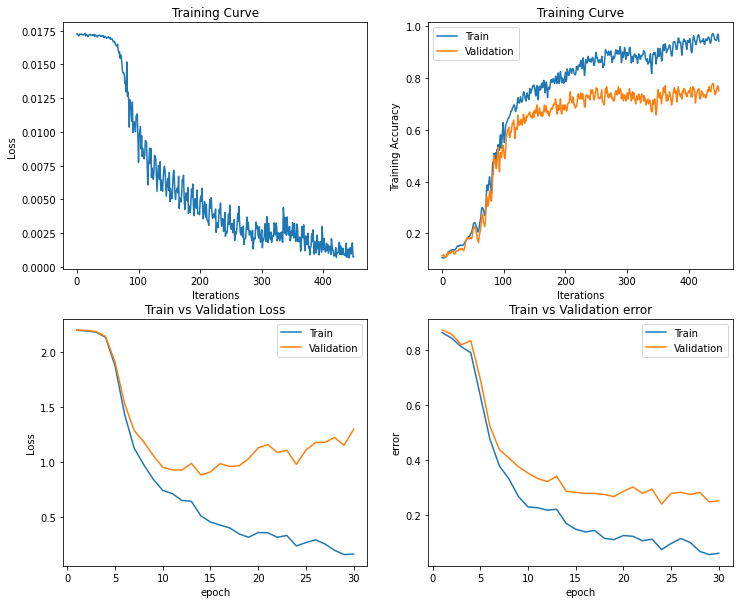

In [ ]:
use_cuda = True

model = Classifier(output_conv1=5, output_conv2=20)

if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')


train(model, train_set, output_conv1=5, output_conv2=20, batch_size=128)

#### <font color=Blue> Tuning learning rate <font color=Blue>

CUDA is available!  Training on GPU ...
Epoch 1: Train err: 0.887, Train loss: 2.205 |Validation err: 0.883, Validation loss: 2.201
Epoch 2: Train err: 0.886, Train loss: 2.202 |Validation err: 0.883, Validation loss: 2.199
Epoch 3: Train err: 0.883, Train loss: 2.199 |Validation err: 0.887, Validation loss: 2.197
Epoch 4: Train err: 0.865, Train loss: 2.194 |Validation err: 0.871, Validation loss: 2.194
Epoch 5: Train err: 0.809, Train loss: 2.188 |Validation err: 0.812, Validation loss: 2.189
Epoch 6: Train err: 0.783, Train loss: 2.179 |Validation err: 0.820, Validation loss: 2.181
Epoch 7: Train err: 0.783, Train loss: 2.163 |Validation err: 0.809, Validation loss: 2.167
Epoch 8: Train err: 0.774, Train loss: 2.133 |Validation err: 0.805, Validation loss: 2.141
Epoch 9: Train err: 0.705, Train loss: 2.071 |Validation err: 0.766, Validation loss: 2.084
Epoch 10: Train err: 0.614, Train loss: 1.933 |Validation err: 0.688, Validation loss: 1.961
Epoch 11: Train err: 0.580, Train loss:

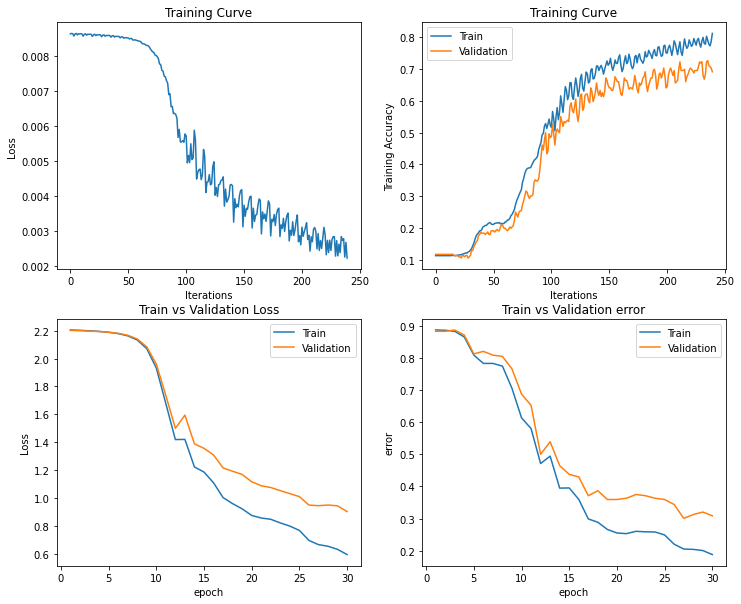

In [ ]:
use_cuda = True

model = Classifier(output_conv1=5, output_conv2=20)

if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')


train(model, train_set, output_conv1=5, output_conv2=20, learning_rate=0.005)

CUDA is available!  Training on GPU ...
Epoch 1: Train err: 0.881, Train loss: 2.188 |Validation err: 0.902, Validation loss: 2.201
Epoch 2: Train err: 0.776, Train loss: 2.109 |Validation err: 0.809, Validation loss: 2.128
Epoch 3: Train err: 0.585, Train loss: 1.634 |Validation err: 0.633, Validation loss: 1.784
Epoch 4: Train err: 0.564, Train loss: 1.495 |Validation err: 0.633, Validation loss: 1.578
Epoch 5: Train err: 0.392, Train loss: 1.163 |Validation err: 0.465, Validation loss: 1.340
Epoch 6: Train err: 0.277, Train loss: 0.870 |Validation err: 0.371, Validation loss: 1.116
Epoch 7: Train err: 0.252, Train loss: 0.741 |Validation err: 0.348, Validation loss: 1.025
Epoch 8: Train err: 0.220, Train loss: 0.638 |Validation err: 0.324, Validation loss: 0.964
Epoch 9: Train err: 0.181, Train loss: 0.537 |Validation err: 0.270, Validation loss: 0.834
Epoch 10: Train err: 0.163, Train loss: 0.491 |Validation err: 0.258, Validation loss: 0.849
Epoch 11: Train err: 0.149, Train loss:

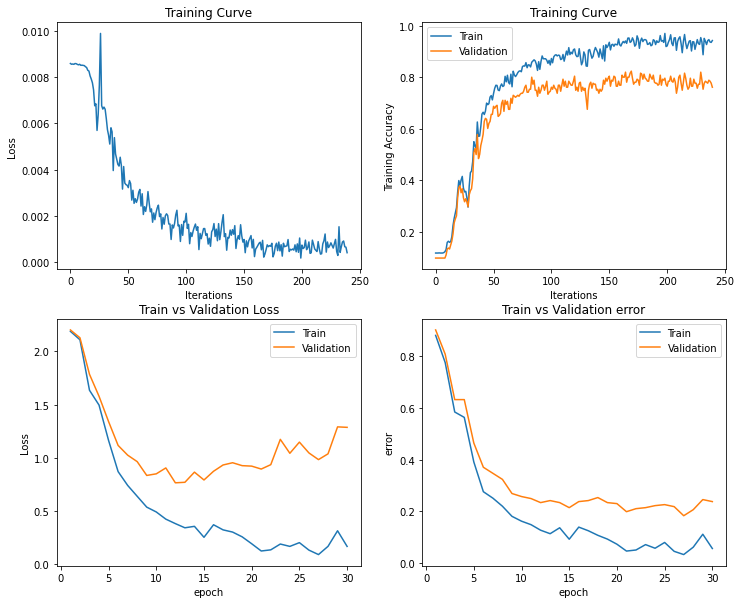

In [ ]:
use_cuda = True

model = Classifier(output_conv1=5, output_conv2=20)

if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')


train(model, train_set, output_conv1=5, output_conv2=20, learning_rate=0.05)


### Part 3(c)

<font color=blue> A model with `output_conv1=5`, `output_conv2=20`,  `batch_size=128`, `learning_rate=0.05`, and when `epoch=27` has been chosen as the best model <font color=Red>

### Part 3(d) - Test accuracy of the chosen model (using test set) was 85% and for validation set, accuracy set was 81.6%

In [ ]:

model = Classifier(output_conv1=5, output_conv2=20)
model_path ="model_bs256_lr0.05_epoch26_conv5_conv20"
state = torch.load(model_path)
model.load_state_dict(state)



<All keys matched successfully>

In [ ]:
criterion = nn.CrossEntropyLoss()
model.cuda()
print("accuracy, loss and Error of the model for test set=", get_accuracy(model, criterion=criterion, batch_size=256, train=True, test=True))

accuracy, loss and Error of the model for test set= (0.8588235294117647, 0.5386776924133301, 0.1411764705882353)


In [ ]:
criterion = nn.CrossEntropyLoss()
model.cuda()
print("accuracy, loss and Error of the model for train set=", get_accuracy(model, criterion=criterion, batch_size=256, train=True))

accuracy, loss and Error of the model for train set= (0.9666666666666667, 0.09095214842818677, 0.03333333333333333)


In [ ]:
criterion = nn.CrossEntropyLoss()
model.cuda()
print("accuracy, loss and Error of the model for validation set=", get_accuracy(model, criterion=criterion, batch_size=256))

accuracy, loss and Error of the model for validation set= (0.81640625, 0.9829964637756348, 0.18359375)


## Part 4. Transfer Learning [8 pt]
For many image classification tasks, it is generally not a good idea to train a very large deep neural network
model from scratch due to the enormous compute requirements and lack of sufficient amounts of training
data.

One of the better options is to try using an existing model that performs a similar task to the one you need
to solve. This method of utilizing a pre-trained network for other similar tasks is broadly termed **Transfer
Learning**. In this assignment, we will use Transfer Learning to extract features from the hand gesture
images. Then, train a smaller network to use these features as input and classify the hand gestures.

As you have learned from the CNN lecture, convolution layers extract various features from the images which
get utilized by the fully connected layers for correct classification. AlexNet architecture played a pivotal
role in establishing Deep Neural Nets as a go-to tool for image classification problems and we will use an
ImageNet pre-trained AlexNet model to extract features in this assignment.

### Part 4(a) -
Here is the code to load the AlexNet network, with pretrained weights. When you first run the code, PyTorch
will download the pretrained weights from the internet.

In [ ]:
import torchvision.models
alexnet = torchvision.models.alexnet(pretrained=True)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


  0%|          | 0.00/233M [00:00<?, ?B/s]

The alexnet model is split up into two components: *alexnet.features* and *alexnet.classifier*. The
first neural network component, *alexnet.features*, is used to compute convolutional features, which are
taken as input in *alexnet.classifier*.

The neural network alexnet.features expects an image tensor of shape Nx3x224x224 as input and it will
output a tensor of shape Nx256x6x6 . (N = batch size).
In the following cell of code a function has been defined to calculate and save alexnet features of  our datasets  for a specificed bach size

In [ ]:
def save_features(batch_size):
  torch.manual_seed(1) # set the random seed
  train_load=torch.utils.data.DataLoader(train_set, batch_size=batch_size)
  val_load=torch.utils.data.DataLoader(val_set, batch_size=batch_size)
  test_load=torch.utils.data.DataLoader(test_set, batch_size=batch_size)


  n=0
  for images, labels in iter(train_load):
    train_features=alexnet.features(images)
    torch.save(train_features,"train_features_save{0}".format(n))
    n+=1

  n=0
  for images, labels in iter(val_load):
    val_features=alexnet.features(images)
    torch.save(val_features,"val_features_save{0}".format(n))
    n+=1

  n=0
  for images, labels in iter(test_load):
    test_features=alexnet.features(images)
    torch.save(test_features,"test_features_save{0}".format(n))




**Save the computed features**.

### Part 4(b) — Transfer Learning Classifier

A lightweight neural network classifier was developed to classify the feature representations extracted by the pretrained AlexNet model. Since the convolutional layers of AlexNet already learn rich visual features, only a small fully connected network is required for the final classification task.

### Model Architecture

The classifier consists of:

- **Two fully connected (linear) layers** for multi-class classification.
- **ReLU activation** between the fully connected layers to introduce non-linearity and improve optimization.
- **No convolutional or pooling layers**, as feature extraction is performed entirely by the pretrained AlexNet model.
- A **hidden layer with 20 units**, providing sufficient model capacity while keeping the classifier lightweight and computationally efficient.

### Design Choices

- The pretrained AlexNet serves as a fixed feature extractor, eliminating the need to train a deep convolutional network from scratch.
- A compact classifier reduces the number of trainable parameters, lowering computational cost and decreasing the risk of overfitting on a relatively small dataset.
- The ReLU activation function enables efficient gradient propagation and faster convergence during training.

In [ ]:
# # features = ... load precomputed alexnet.features(img) ...
# output = model(features)
# prob = F.softmax(output)

In [ ]:
#Artifical Neural Network Architecture
class Model_features(nn.Module):
    def __init__(self):
        super(Model_features, self).__init__()
        self.fc1 = nn.Linear(256 * 6 * 6, 20)
        self.fc2 = nn.Linear(20, 9)

    def forward(self, x):
        x = x.view(-1, 256 * 6 * 6) #flatten feature data
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

### Part 4 (c)
Train your new network, including any hyperparameter tuning. Plot and submit the training curve of your
best model only.

Note: Depending on how you are caching (saving) your AlexNet features, PyTorch might still be tracking
updates to the **AlexNet weights**, which we are not tuning. One workaround is to convert your AlexNet
feature tensor into a numpy array, and then back into a PyTorch tensor.

In [ ]:
def get_accuracy(model, criterion, batch_size, train=False, test=False):
    if test:
      data=test_set
      a="test_features_save"
    else:
      if train:
        data = train_set
        a="train_features_save"
      else:
        data = val_set
        a="val_features_save"


    correct = 0
    error=0
    total = 0
    total_loss = 0.0
    n=0
    for i, data in enumerate(torch.utils.data.DataLoader(data, batch_size=batch_size), 0):
        imgs, labels = data
        if test:
          imgs=alexnet.features(imgs)
        else:
          imgs=torch.load(a+"{0}".format(n))
        n+=1
        imgs = torch.from_numpy(imgs.detach().numpy())
        #############################################
        #To Enable GPU Usage
        if use_cuda and torch.cuda.is_available():
          imgs = imgs.cuda()
          labels = labels.cuda()
        #############################################


        output = model(imgs)

        loss = criterion(output, labels)

        #select index with maximum prediction score
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred)).sum().item()
        error += pred.ne(labels.view_as(pred)).sum().item()
        total += imgs.shape[0]
        total_loss += loss.item()
    acc=correct/ total
    err=error/ total
    loss = float(total_loss) / (i + 1)
    return acc, loss, err


In [ ]:
def trainNet(model, data,  batch_size=256, learning_rate=0.01, num_epochs=30):
    torch.manual_seed(1000)
    train_loader = torch.utils.data.DataLoader(data, batch_size=batch_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

    iters, losses, train_acc, val_acc = [], [], [], []
    losses_val= []
    losses_train= []
    val_err= []
    train_err= []

    # training
    n = 0 # the number of iterations
    start_time = time.time()
    for epoch in range(num_epochs):
        m=0
        for imgs, labels in iter(train_loader):


            #############################################
            imgs=torch.load("train_features_save{0}".format(m))
            imgs = torch.from_numpy(imgs.detach().numpy())
            m+=1
            #To Enable GPU Usage
            if use_cuda and torch.cuda.is_available():
              imgs = imgs.cuda()
              labels = labels.cuda()
            #############################################


            out = model(imgs)             # forward pass
            loss = criterion(out, labels) # compute the total loss
            loss.backward()               # backward pass (compute parameter updates)
            optimizer.step()              # make the updates for each parameter
            optimizer.zero_grad()         # a clean up step for PyTorch

            # save the current training information
            iters.append(n)
            losses.append(float(loss)/batch_size)             # compute *average* loss
            train_acc.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=True)[0]) # compute training accuracy
            val_acc.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=False)[0])  # compute validation accuracy
            n += 1

        losses_train.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=True)[1])  # compute validation loss
        losses_val.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=False)[1])  # compute validation loss
        train_err.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=True)[2]) # compute training accuracy
        val_err.append(get_accuracy(model,criterion=criterion,batch_size=batch_size, train=False)[2])  # compute validation accuracy
        print(("Epoch {}: Train err: {:.3f}, Train loss: {:.3f} |"+
               "Validation err: {:.3f}, Validation loss: {:.3f}").format(
                   epoch + 1,
                   train_err[epoch],
                   losses_train[epoch],
                   val_err[epoch],
                   losses_val[epoch]))

        # Save the current model (checkpoint) to a file
        model_path ="model_2_bs{0}_lr{1}_epoch{2}".format(batch_size,
                                                   learning_rate,
                                                   epoch)
        torch.save(model.state_dict(), model_path)
    print('Finished Training')
    end_time = time.time()
    elapsed_time = end_time - start_time
    print("Total time elapsed: {:.2f} seconds".format(elapsed_time))
    # Write the train/test loss/err into CSV file for plotting later
    epochs = np.arange(1, num_epochs + 1)
    np.savetxt("{}_train_err.csv".format(model_path), train_acc)
    np.savetxt("{}_train_loss.csv".format(model_path), losses)
    np.savetxt("{}_val_err.csv".format(model_path), val_acc)
    # np.savetxt("{}_val_loss.csv".format(model_path), val_loss)


    # plotting
    fig = plt.figure(figsize=(12, 10))
    plt.subplot(2, 2, 1)
    plt.title("Training Curve")
    plt.plot(iters, losses, label="Train")
    plt.xlabel("Iterations")
    plt.ylabel("Loss")

    plt.subplot(2, 2, 2)
    plt.title("Training Curve")
    plt.plot(iters, train_acc, label="Train")
    plt.plot(iters, val_acc, label="Validation")
    plt.xlabel("Iterations")
    plt.ylabel("Training Accuracy")
    plt.legend(loc='best')

    x = len(losses_train)
    plt.subplot(2, 2, 3)
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,x+1), losses_train, label="Train")
    plt.plot(range(1,x+1), losses_val, label="Validation")
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')

    plt.subplot(2, 2, 4)
    plt.title("Train vs Validation error")
    plt.plot(range(1,x+1), train_err, label="Train")
    plt.plot(range(1,x+1), val_err, label="Validation")
    plt.xlabel("epoch")
    plt.ylabel("error")
    plt.legend(loc='best')


    print("Final Training Accuracy: {}".format(train_acc[-1]))
    print("Final Validation Accuracy: {}".format(val_acc[-1]))

CUDA is available!  Training on GPU ...
Epoch 1: Train err: 0.161, Train loss: 0.514 |Validation err: 0.199, Validation loss: 0.662
Epoch 2: Train err: 0.070, Train loss: 0.243 |Validation err: 0.152, Validation loss: 0.461
Epoch 3: Train err: 0.060, Train loss: 0.187 |Validation err: 0.156, Validation loss: 0.454
Epoch 4: Train err: 0.033, Train loss: 0.119 |Validation err: 0.129, Validation loss: 0.419
Epoch 5: Train err: 0.015, Train loss: 0.073 |Validation err: 0.125, Validation loss: 0.344
Epoch 6: Train err: 0.023, Train loss: 0.086 |Validation err: 0.125, Validation loss: 0.398
Epoch 7: Train err: 0.016, Train loss: 0.066 |Validation err: 0.117, Validation loss: 0.402
Epoch 8: Train err: 0.020, Train loss: 0.076 |Validation err: 0.117, Validation loss: 0.440
Epoch 9: Train err: 0.019, Train loss: 0.068 |Validation err: 0.113, Validation loss: 0.450
Epoch 10: Train err: 0.015, Train loss: 0.059 |Validation err: 0.133, Validation loss: 0.457
Epoch 11: Train err: 0.008, Train loss:

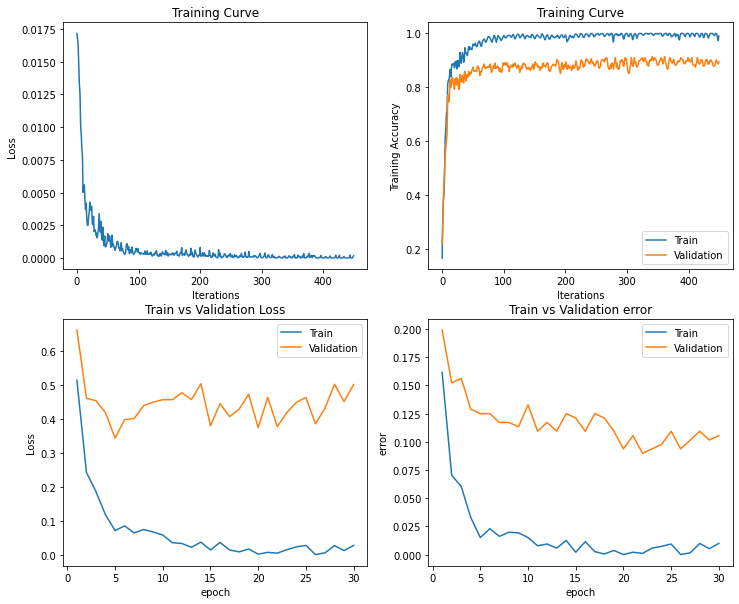

In [ ]:
batch_size=128
use_cuda = True
save_features(batch_size=batch_size)
model = Model_features()
if use_cuda and torch.cuda.is_available():
  model.cuda()
  print('CUDA is available!  Training on GPU ...')
else:
  print('CUDA is not available.  Training on CPU ...')


trainNet(model, train_set, batch_size=batch_size, learning_rate=0.01)

### Part 4(d) Test accuracy of the  model (using transfer learning) was 94.9%. By using transfer learning the test accuracy has increased by 10 %

In [ ]:
model = Model_features()
model_path ="model_2_bs128_lr0.01_epoch21"
state = torch.load(model_path)
model.load_state_dict(state)




<All keys matched successfully>

In [ ]:
criterion = nn.CrossEntropyLoss()
model.cuda()
print("accuracy, loss and Error of the model for test set=", get_accuracy(model, criterion=criterion, batch_size=128, train=True, test=True))

accuracy, loss and Error of the model for test set= (0.9490196078431372, 0.18021557480096817, 0.050980392156862744)
